In [1]:
import os
import pandas as pd
import numpy as np 
import seaborn as sns
from tqdm import tqdm

from pydub import AudioSegment
from pydub.utils import make_chunks
from IPython.display import Audio
from scipy import signal

import librosa
import librosa.display
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedShuffleSplit

from tqdm import tqdm

from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")

In [2]:
CHUNK_LENGTH = 5000 # pydub calculates in millisec

def convert_to_mono(audio):
    """Convert stereo audio to mono."""
    return audio.set_channels(1)

def get_split_unique(path, base_filename):
    """
    Splits an audio file into 1.5-second chunks and names each chunk uniquely.

    Args:
        path (str): The file path to the input audio file.
        base_filename (str): The base name to use for naming the chunk files.

    Returns:
        list: A list of in-memory audio chunks.
    """
    # Carga el archivo de audio
    try:
        audio = AudioSegment.from_file(path, "mp3")
    except Exception as e:
        print(f"Error al cargar el archivo de audio {path}: {e}")
        os.remove(path)
        return []
    
    mono_audio = convert_to_mono(audio)
    chunk_length_ms = CHUNK_LENGTH  
    chunks = make_chunks(mono_audio, chunk_length_ms)

    # Ensure that the chunks directory exists
    if not os.path.exists("chunks"):
        os.makedirs("chunks")

    paths = []
    for i, chunk in enumerate(tqdm(chunks, desc="Processing chunks")):
        chunk_name = f"chunks/{base_filename}_chunk{i}.mp3"  # Unique naming
        
        # Check if the chunk file already exists
        if not os.path.exists(chunk_name):
            chunk.export(chunk_name, format="mp3")
            paths.append(chunk_name)
        else:
            #print(f"Chunk {chunk_name} already exists, skipping.")
            paths.append(chunk_name)

    return paths

def get_split_with_label(row):
    """
    Splits an audio file into chunks and associates each chunk with the audio's original label.

    Args:
        row (pd.Series): A row from a DataFrame containing 'audio_path' and 'label'.

    Returns:
        list of tuples: A list of tuples, where each tuple contains the path to a chunk and the label.
    """
    path = row['audio_path']
    label = row['label']
    base_filename = os.path.splitext(os.path.basename(path))[0]
    chunk_paths = get_split_unique(path, base_filename)
    return [(chunk_path, label) for chunk_path in chunk_paths]

In [3]:
#df = pd.read_csv('./data/train_muestra.csv')
#df = pd.read_csv('./data/val_muestra.csv')
df = pd.read_csv('./data/test_muestra.csv')
df = df[['audio_path', 'label']]
print(df.shape)
df.shape

(462, 2)


(462, 2)

In [4]:
#df = df[~df['audio_path'].str.contains(r'./songs\\Tyrannidae\\Megarynchus\\Megarynchus pitangua\\Boat-billedFlycatcher\\295771.mp3')]

In [5]:
chunk_data = df.apply(get_split_with_label, axis=1)
chunk_data = [item for sublist in chunk_data for item in sublist]
chunk_df = pd.DataFrame(chunk_data, columns=['audio_path', 'label'])

Processing chunks: 100%|██████████| 18/18 [00:03<00:00,  5.74it/s]


In [6]:
print(chunk_df.shape)
chunk_df.sample(4)

(4398, 2)


,audio_path,label
983,chunks/475808_chunk5.mp3,Microcerculus marginatus
3430,chunks/420563_chunk3.mp3,Henicorhina leucosticta
1913,chunks/785602_chunk3.mp3,Thryophilus nicefori
3822,chunks/45426_chunk0.mp3,Henicorhina negreti


In [7]:
chunk_df['label'].value_counts()

label
Troglodytes aedon               927
Henicorhina leucophrys          449
Cantorchilus nigricapillus      305
Henicorhina leucosticta         272
Microcerculus marginatus        211
Cantorchilus leucotis           192
Pheugopedius euophrys           178
Cistothorus platensis           150
Campylorhynchus turdinus        147
Pheugopedius genibarbis         143
Pheugopedius coraya             143
Cyphorhinus arada               117
Pheugopedius fasciatoventris    113
Cyphorhinus thoracicus          109
Pheugopedius mystacalis         103
Thryophilus rufalbus            101
Cyphorhinus phaeocephalus        95
Cinnycerthia olivascens          74
Cistothorus apolinari            69
Pheugopedius sclateri            69
Microcerculus bambla             63
Campylorhynchus griseus          47
Cantorchilus griseus             46
Troglodytes solstitialis         46
Pheugopedius rutilus             44
Cinnycerthia unirufa             35
Cantorchilus leucopogon          30
Campylorhynchus zonatu

In [8]:
# filtrar los labels mayores a 1
labels = chunk_df['label'].value_counts()
labels = labels[labels > 1].index
chunk_df = chunk_df[chunk_df['label'].isin(labels)]
chunk_df['label'].value_counts()

label
Troglodytes aedon               927
Henicorhina leucophrys          449
Cantorchilus nigricapillus      305
Henicorhina leucosticta         272
Microcerculus marginatus        211
Cantorchilus leucotis           192
Pheugopedius euophrys           178
Cistothorus platensis           150
Campylorhynchus turdinus        147
Pheugopedius genibarbis         143
Pheugopedius coraya             143
Cyphorhinus arada               117
Pheugopedius fasciatoventris    113
Cyphorhinus thoracicus          109
Pheugopedius mystacalis         103
Thryophilus rufalbus            101
Cyphorhinus phaeocephalus        95
Cinnycerthia olivascens          74
Cistothorus apolinari            69
Pheugopedius sclateri            69
Microcerculus bambla             63
Campylorhynchus griseus          47
Cantorchilus griseus             46
Troglodytes solstitialis         46
Pheugopedius rutilus             44
Cinnycerthia unirufa             35
Cantorchilus leucopogon          30
Campylorhynchus zonatu

In [9]:
chunk_df.to_csv('./data/chunks_specie_sample_test.csv', index=False)

In [10]:
data = pd.read_csv('./data/chunks_specie_sample_test.csv')

In [11]:
# graficar spectograma
def plot_spectrogram(audio_path):
    y, sr = librosa.load(audio_path)
    plt.figure(figsize=(10, 4))
    D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
    librosa.display.specshow(D, y_axis='log', x_axis='time')
    plt.colorbar(format='%+2.0f dB')
    plt.title('Spectrogram')
    plt.tight_layout()
    plt.show()

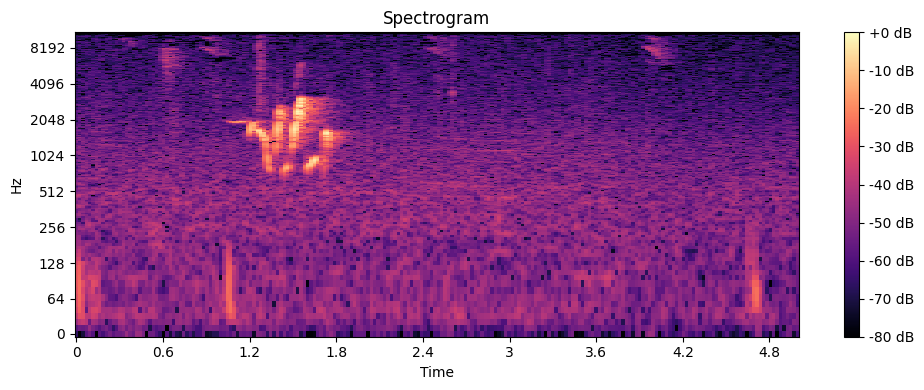

In [12]:
idx = np.random.randint(0, data.shape[0])
plot_spectrogram(data['audio_path'].iloc[idx])

In [13]:
AudioSegment.from_file(data['audio_path'].iloc[idx], "mp3")

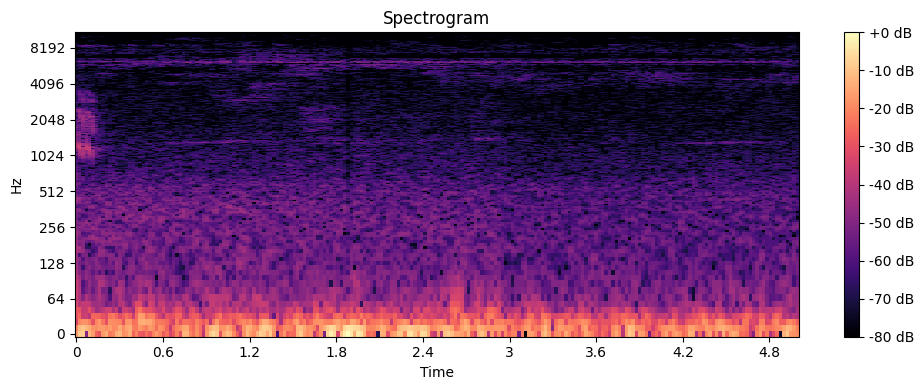

In [14]:
idx = np.random.randint(0, data.shape[0])
plot_spectrogram(data['audio_path'].iloc[idx])

In [15]:
AudioSegment.from_file(data['audio_path'].iloc[idx], "mp3")

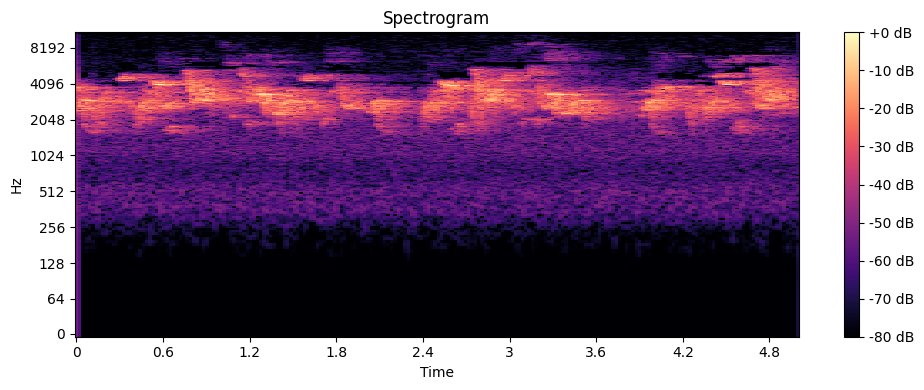

In [16]:
idx = np.random.randint(0, data.shape[0])
plot_spectrogram(data['audio_path'].iloc[idx])

In [17]:
AudioSegment.from_file(data['audio_path'].iloc[idx], "mp3")

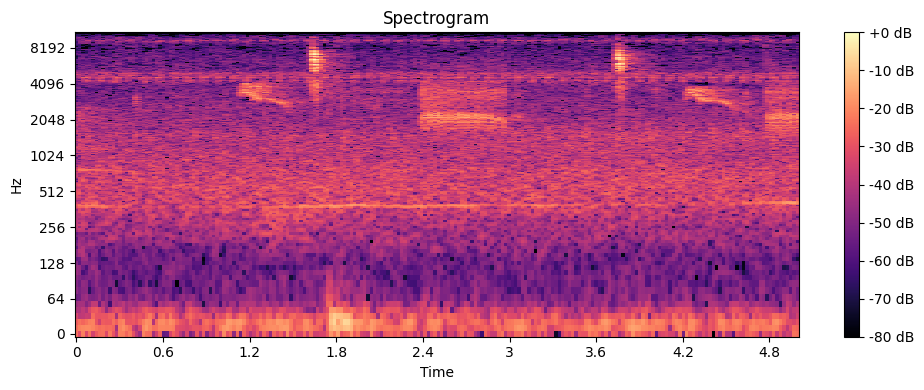

In [18]:
idx = np.random.randint(0, data.shape[0])
plot_spectrogram(data['audio_path'].iloc[idx])

In [19]:
AudioSegment.from_file(data['audio_path'].iloc[idx], "mp3")